(The cells must be executed sequentially)

In [1]:
from common_functions import *
import matplotlib as mpl

In [2]:
def draw_domain(ax, xEE, yEE):
    # blue line and text which distinguishes lower boundary
    ax.axhline(y=0, color='dodgerblue', linestyle='-', zorder=0)
    ax.text(1.01, -0.04, r"$\partial\Omega_1$", color='dodgerblue')

    # red line and text which distinguishes upper boundary
    ax.axhline(y=yEE, color='red', linestyle='-', zorder=0)
    ax.text(1.01, yEE - 0.04, r"$\partial\Omega_0$", color='red')

    # black dot and text which distinguishes endemic equilibrium
    ax.scatter(xEE, yEE, s=15, color='k', zorder=1)
    ax.text(xEE + 0.01, yEE + 0.08, r"$P_{\mathrm{EE}}$", color='k', zorder=1)

    # create and add a rectangle patch to shade the domain
    rect = mpl.patches.Rectangle((0, 0), 1, yEE, color='purple', alpha=0.1, zorder=-1)
    ax.add_patch(rect)
    ax.text(0.8, (yEE / 2) - 0.04, r"$\Omega$", color='purple')

# DRAWING FOR AUTONOMOUS MODEL

In [3]:
# parameter values
g = 0.8; b = 2 * g; d = 0.025

# simulation length and time step
sim_len = 2.3; dt = 0.000009

# initialize population fractions
y0       = 0.001 / d         # initial proportion of infecteds measure in $\tilde{y}$
initials = [1 - d * y0, y0]  # initial population proportions: x0, y0

# get example trajectory from deterministic simulation
t, x_list, y_list = sim_SIRS_scaled(sim_len, dt, initials, b, d, g)

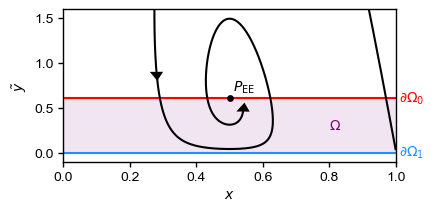

In [4]:
set_rcParams()

# figure dimensions
fig_height = 2          # width (in inches)
fig_width  = 4.7 * 0.9  # height (in inches)

# initialize figure
fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))

# plot trajectory
ax.plot(x_list, y_list, 'k')

# axis limits
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 1.6)

# variables store x-coordinate and y-coordinate, respectively, of endemic equilibrium
xEE, yEE = get_EE_scaled(b, d, g)

# draw purple rectangle with red and blue boundaries
draw_domain(ax, xEE, yEE)

# set axis labels
ax.set_ylabel(r"$\tilde{y}$")
ax.set_xlabel(r'$x$')

# add arrows to show trajectory moves counter clockwise
idx    = int(len(x_list) // 6)
arrow1 = x_list[idx+1], y_list[idx+1], x_list[idx+1] - x_list[idx], y_list[idx+1] - y_list[idx]
ax.arrow(*arrow1, shape='full', lw=0, head_width=0.04, head_length=0.1, color='k')

arrow2 = x_list[-1], y_list[-1], x_list[-1]-x_list[-2], y_list[-1]-y_list[-2]
ax.arrow(*arrow2, shape='full', lw=0, head_width=0.04, head_length=0.1, color='k')

# save figure
plt.savefig("plots/domain.pdf", bbox_inches="tight", dpi=600)

# DRAWING FOR NONAUTONOMOUS MODEL

In [5]:
# parameter values
g = 0.8; b = 2.2; d = 1 / 52
A = 0.21; p = 0; w = 52

# period of the forcing
forcing_period = abs(d * w)

# simulation length and time step
sim_len = 150 * forcing_period; dt = 0.00005

# get example trajectory
t_list, x_list, y_list = sim_SIRS_scaled(sim_len, dt, initials, b, d, g, A, p, w)

# extract the terminal year from simulation data
n_periods  = 1
cutoff_idx = int((sim_len - n_periods * forcing_period) / dt)

x = x_list[cutoff_idx:]
y = y_list[cutoff_idx:]
t = t_list[cutoff_idx:]

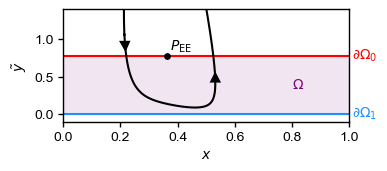

In [6]:
# figure dimensions
fig_height = 1.6          # width (in inches)
fig_width  = 4.7 * 0.8  # height (in inches)

# initialize figure
fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))

# plot trajectory
ax.plot(x, y, 'k')

# axis limits
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 1.4)

# variables store x-coordinate and y-coordinate, respectively, of endemic equilibrium
xEE, yEE = get_EE_scaled(b, d, g)

# draw purple rectangle with red and blue boundaries
draw_domain(ax, xEE, yEE)

# set axis labels
ax.set_ylabel(r"$\tilde{y}$")
ax.set_xlabel(r'$x$')

# add arrows to show trajectory moves counter clockwise
idx1  = int(len(x) // 150)
arrow = x[idx1 + 1], y[idx1 + 1], x[idx1 + 1] - x[idx1], y[idx1 + 1] - y[idx1]
ax.arrow(*arrow, shape='full', lw=0, head_width=0.04, head_length=0.15, color='k')

idx2  = int(len(x) // 1.4)
arrow = x[idx2 + 1], y[idx2 + 1], x[idx2 + 1] - x[idx2], y[idx2 + 1] - y[idx2]
ax.arrow(*arrow, shape='full', lw=0, head_width=0.04, head_length=0.15, color='k')

# save figure
plt.savefig("plots/domain_forced.pdf", bbox_inches="tight", dpi=600)